In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")
print(f"\nFeature range: {X.min():.2f} to {X.max():.2f}")

Dataset Information:
Number of samples: 1797
Number of features: 64
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]

Feature range: 0.00 to 16.00


In [9]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split Information:")
print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")
print(f"Feature scaling completed")

Data Split Information:
Training set size: 1437
Test set size: 360
Feature scaling completed


In [4]:
kernels = ['rbf', 'linear', 'poly']
results = {}
trained_models = {}

print("Training SVM models with different kernels...\n")

for kernel in kernels:
    print(f"Training SVM with kernel: {kernel}")
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    
    y_pred_train = svm_model.predict(X_train_scaled)
    y_pred_test = svm_model.predict(X_test_scaled)
    
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='weighted')
    test_precision = precision_score(y_test, y_pred_test, average='weighted')
    train_recall = recall_score(y_train, y_pred_train, average='weighted')
    test_recall = recall_score(y_test, y_pred_test, average='weighted')
    train_f1 = f1_score(y_train, y_pred_train, average='weighted')
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')
    
    results[kernel] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_precision': train_precision,
        'test_precision': test_precision,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'n_support_vectors': svm_model.n_support_
    }
    
    trained_models[kernel] = svm_model
    
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")
    print(f"  Test Recall: {test_recall:.4f}")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print(f"  Support Vectors: {svm_model.n_support_.sum()}\n")

Training SVM models with different kernels...

Training SVM with kernel: rbf
  Test Accuracy: 0.9750
  Test Precision: 0.9759
  Test Recall: 0.9750
  Test F1-Score: 0.9749
  Support Vectors: 746

Training SVM with kernel: linear
  Test Accuracy: 0.9750
  Test Precision: 0.9754
  Test Recall: 0.9750
  Test F1-Score: 0.9749
  Support Vectors: 429

Training SVM with kernel: poly
  Test Accuracy: 0.9722
  Test Precision: 0.9760
  Test Recall: 0.9722
  Test F1-Score: 0.9731
  Support Vectors: 810



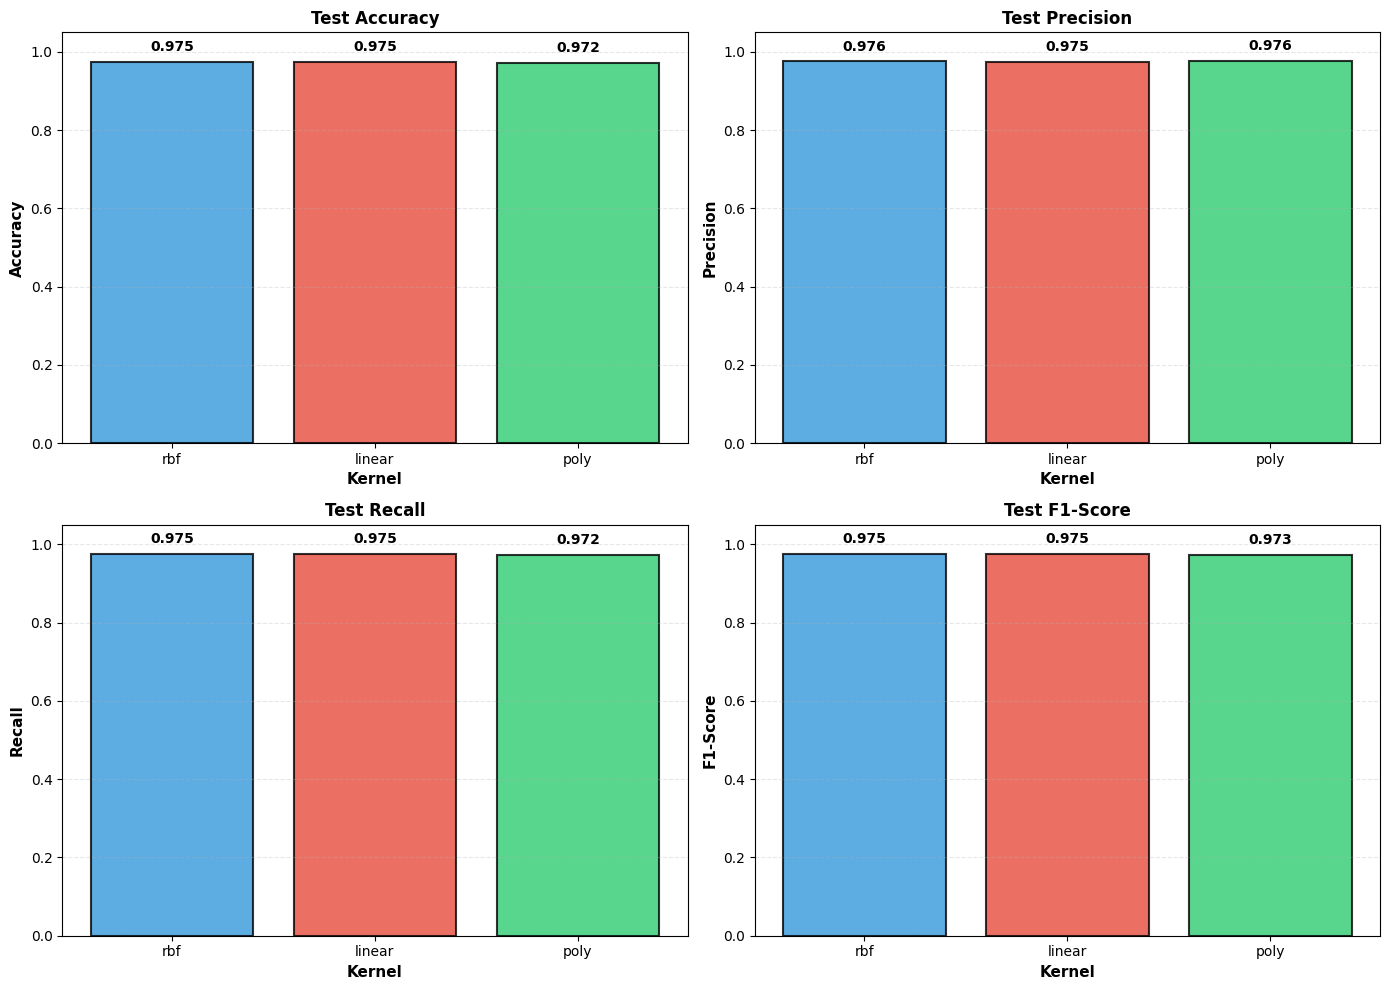

Visualization complete


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    values = [results[kernel][metric] for kernel in kernels]
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    bars = ax.bar(kernels, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Kernel', fontsize=11, fontweight='bold')
    ax.set_title(f'Test {metric_name}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print("Visualization complete")

In [6]:
comparison_data = []

for kernel in kernels:
    comparison_data.append({
        'Kernel': kernel.upper(),
        'Train Accuracy': f"{results[kernel]['train_accuracy']:.4f}",
        'Test Accuracy': f"{results[kernel]['test_accuracy']:.4f}",
        'Train Precision': f"{results[kernel]['train_precision']:.4f}",
        'Test Precision': f"{results[kernel]['test_precision']:.4f}",
        'Train Recall': f"{results[kernel]['train_recall']:.4f}",
        'Test Recall': f"{results[kernel]['test_recall']:.4f}",
        'Train F1-Score': f"{results[kernel]['train_f1']:.4f}",
        'Test F1-Score': f"{results[kernel]['test_f1']:.4f}",
        'Support Vectors': int(results[kernel]['n_support_vectors'].sum())
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*140)
print("COMPREHENSIVE KERNEL COMPARISON TABLE")
print("="*140)
print(comparison_df.to_string(index=False))
print("="*140)


COMPREHENSIVE KERNEL COMPARISON TABLE
Kernel Train Accuracy Test Accuracy Train Precision Test Precision Train Recall Test Recall Train F1-Score Test F1-Score  Support Vectors
   RBF         0.9972        0.9750          0.9972         0.9759       0.9972      0.9750         0.9972        0.9749              746
LINEAR         1.0000        0.9750          1.0000         0.9754       1.0000      0.9750         1.0000        0.9749              429
  POLY         0.9826        0.9722          0.9848         0.9760       0.9826      0.9722         0.9831        0.9731              810


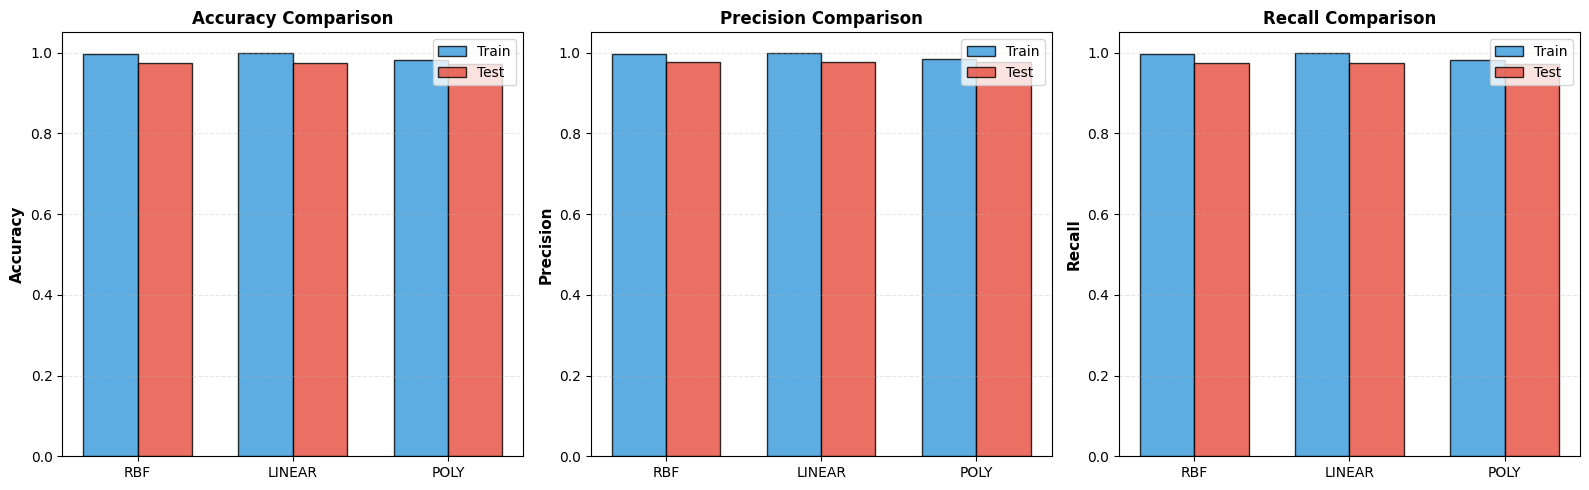

Train vs Test comparison complete


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_pair = [
    ('train_accuracy', 'test_accuracy', 'Accuracy'),
    ('train_precision', 'test_precision', 'Precision'),
    ('train_recall', 'test_recall', 'Recall')
]

x = np.arange(len(kernels))
width = 0.35

for idx, (train_metric, test_metric, title) in enumerate(metrics_pair):
    ax = axes[idx]
    
    train_vals = [results[kernel][train_metric] for kernel in kernels]
    test_vals = [results[kernel][test_metric] for kernel in kernels]
    
    bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#e74c3c', alpha=0.8, edgecolor='black')
    
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(f'{title} Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([k.upper() for k in kernels])
    ax.legend()
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print("Train vs Test comparison complete")

In [8]:
print("\n" + "="*100)
print("SUMMARY AND INSIGHTS")
print("="*100)

best_kernel_acc = max(kernels, key=lambda k: results[k]['test_accuracy'])
best_kernel_f1 = max(kernels, key=lambda k: results[k]['test_f1'])
best_kernel_sv = min(kernels, key=lambda k: results[k]['n_support_vectors'].sum())

print(f"\nBest Test Accuracy: {best_kernel_acc.upper()} with {results[best_kernel_acc]['test_accuracy']:.4f}")
print(f"Best Test F1-Score: {best_kernel_f1.upper()} with {results[best_kernel_f1]['test_f1']:.4f}")
print(f"Least Support Vectors: {best_kernel_sv.upper()} with {results[best_kernel_sv]['n_support_vectors'].sum()} vectors")

print("\nKernel Characteristics:")
for kernel in kernels:
    print(f"\n{kernel.upper()} Kernel:")
    print(f"  - Test Accuracy: {results[kernel]['test_accuracy']:.4f}")
    print(f"  - Test F1-Score: {results[kernel]['test_f1']:.4f}")
    print(f"  - Overfitting Gap (Acc): {(results[kernel]['train_accuracy'] - results[kernel]['test_accuracy']):.4f}")
    print(f"  - Support Vectors: {results[kernel]['n_support_vectors'].sum()}")

print("\n" + "="*100)


SUMMARY AND INSIGHTS

Best Test Accuracy: RBF with 0.9750
Best Test F1-Score: RBF with 0.9749
Least Support Vectors: LINEAR with 429 vectors

Kernel Characteristics:

RBF Kernel:
  - Test Accuracy: 0.9750
  - Test F1-Score: 0.9749
  - Overfitting Gap (Acc): 0.0222
  - Support Vectors: 746

LINEAR Kernel:
  - Test Accuracy: 0.9750
  - Test F1-Score: 0.9749
  - Overfitting Gap (Acc): 0.0250
  - Support Vectors: 429

POLY Kernel:
  - Test Accuracy: 0.9722
  - Test F1-Score: 0.9731
  - Overfitting Gap (Acc): 0.0104
  - Support Vectors: 810

